# Olasılık ve Tahmin Buluşuyor
## Titanic Veri Seti ile Makine Öğrenimine Giriş

**Olasılık ve Rastgele Değişkenler Dersi**  
**Güz 2025**

---

## Kütüphane İçe Aktarımları

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

---
# Bölüm 1: Veri Hazırlama ve Analiz
---

## 1.1 Veri Setini Yükleme

In [2]:
data = pd.read_csv('data 1.csv')
print("Veri setinin ilk 5 satırı:")
data.head()

Veri setinin ilk 5 satırı:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(f"Veri seti boyutu: {data.shape[0]} satır, {data.shape[1]} sütun")
print("\nVeri seti bilgileri:")
data.info()

Veri seti boyutu: 891 satır, 12 sütun

Veri seti bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 1.2 Eksik Değerleri Tespit Etme

In [4]:
missing_data = pd.DataFrame({
    'Eksik Sayısı': data.isnull().sum(),
    'Yüzde': (data.isnull().sum() / len(data) * 100).round(2)
})
missing_data = missing_data[missing_data['Eksik Sayısı'] > 0].sort_values(
    by='Eksik Sayısı', ascending=False
)
print("Eksik Değer Özeti:")
print(missing_data)

Eksik Değer Özeti:
          Eksik Sayısı  Yüzde
Cabin              687  77.10
Age                177  19.87
Embarked             2   0.22


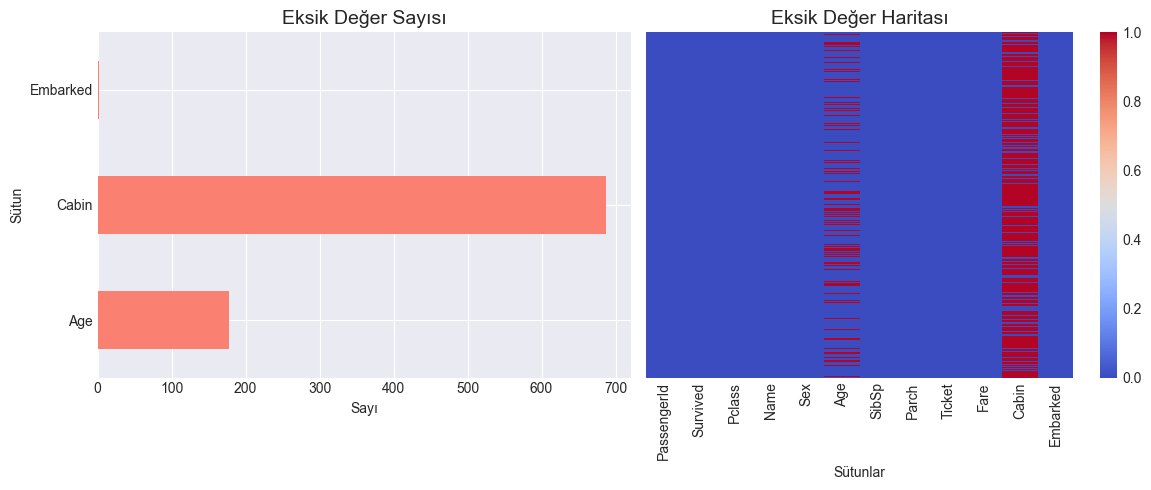

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
missing_counts = data.isnull().sum()[data.isnull().sum() > 0]
missing_counts.plot(kind='barh', color='salmon')
plt.title('Eksik Değer Sayısı', fontsize=14)
plt.xlabel('Sayı')
plt.ylabel('Sütun')

plt.subplot(1, 2, 2)
sns.heatmap(data.isnull(), cbar=True, cmap='coolwarm', yticklabels=False)
plt.title('Eksik Değer Haritası', fontsize=14)
plt.xlabel('Sütunlar')

plt.tight_layout()
plt.show()

## 1.3 Histogram Oluşturma

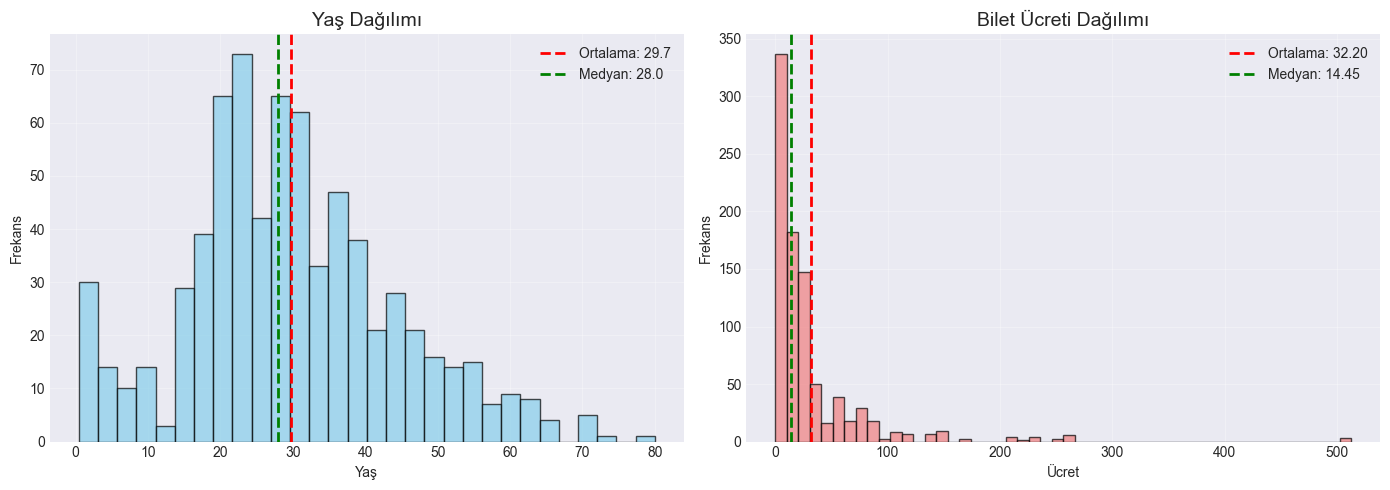

Yaş İstatistikleri: Ortalama=29.70, Medyan=28.00, Std=14.53
Ücret İstatistikleri: Ortalama=32.20, Medyan=14.45, Std=49.69


In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
age_data = data['Age'].dropna()
plt.hist(age_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(age_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Ortalama: {age_data.mean():.1f}')
plt.axvline(age_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Medyan: {age_data.median():.1f}')
plt.title('Yaş Dağılımı', fontsize=14)
plt.xlabel('Yaş')
plt.ylabel('Frekans')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
fare_data = data['Fare'].dropna()
plt.hist(fare_data, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(fare_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Ortalama: {fare_data.mean():.2f}')
plt.axvline(fare_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Medyan: {fare_data.median():.2f}')
plt.title('Bilet Ücreti Dağılımı', fontsize=14)
plt.xlabel('Ücret')
plt.ylabel('Frekans')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Yaş İstatistikleri: Ortalama={age_data.mean():.2f}, Medyan={age_data.median():.2f}, Std={age_data.std():.2f}")
print(f"Ücret İstatistikleri: Ortalama={fare_data.mean():.2f}, Medyan={fare_data.median():.2f}, Std={fare_data.std():.2f}")

## 1.4 Değişkenleri Ayrık veya Sürekli Olarak Sınıflandırma

In [7]:
variable_classification = {
    'Değişken': ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 
                 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
    'Tip': ['Ayrık', 'Ayrık', 'Ayrık', 'Kategorik', 'Ayrık', 'Sürekli',
            'Ayrık', 'Ayrık', 'Kategorik', 'Sürekli', 'Kategorik', 'Ayrık'],
    'Gerekçe': [
        'Sayılabilir benzersiz kimlik değerleri',
        'İkili: 0 veya 1 (hayatta kalma durumu)',
        'Sayılabilir: 1, 2, 3 (sınıf kategorileri)',
        'Metin verisi',
        'İkili kategorik: erkek/kadın',
        'Sürekli: gerçek sayılar, kesirli değerler içerebilir',
        'Sayılabilir: 0, 1, 2, ... (kardeş/eş sayısı)',
        'Sayılabilir: 0, 1, 2, ... (ebeveyn/çocuk sayısı)',
        'Kategorik metin/sayı kombinasyonu',
        'Sürekli: ondalık değerlere sahip gerçek sayılar (bilet ücreti)',
        'Kategorik metin',
        'Kategorik: C, Q, S (biniş limanı)'
    ]
}

classification_df = pd.DataFrame(variable_classification)
classification_df

,Değişken,Tip,Gerekçe
0,PassengerId,Ayrık,Sayılabilir benzersiz kimlik değerleri
1,Survived,Ayrık,İkili: 0 veya 1 (hayatta kalma durumu)
2,Pclass,Ayrık,"Sayılabilir: 1, 2, 3 (sınıf kategorileri)"
3,Name,Kategorik,Metin verisi
4,Sex,Ayrık,İkili kategorik: erkek/kadın
5,Age,Sürekli,"Sürekli: gerçek sayılar, kesirli değerler içer..."
6,SibSp,Ayrık,"Sayılabilir: 0, 1, 2, ... (kardeş/eş sayısı)"
7,Parch,Ayrık,"Sayılabilir: 0, 1, 2, ... (ebeveyn/çocuk sayısı)"
8,Ticket,Kategorik,Kategorik metin/sayı kombinasyonu
9,Fare,Sürekli,Sürekli: ondalık değerlere sahip gerçek sayıla...


**Özet:**

Ayrık rastgele değişkenler Olasılık Kütle Fonksiyonları (PMF) kullanırken, sürekli rastgele değişkenler Olasılık Yoğunluk Fonksiyonları (PDF) kullanır. Bu sınıflandırma, analiz için uygun istatistiksel yöntemleri belirler.

## 1.5 Eksik Verileri İşleme

In [8]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data['Cabin'].fillna('Unknown', inplace=True)

print("İşleme sonrası eksik değerler:")
print(data.isnull().sum())

İşleme sonrası eksik değerler:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


---
# Bölüm 2: Olasılık ve Rastgele Değişkenler
---

## 2.1 Temel Olasılık

In [9]:
total_passengers = len(data)
survived_count = data['Survived'].sum()
p_survived = survived_count / total_passengers

print(f"Toplam yolcu: {total_passengers}")
print(f"Hayatta kalan: {survived_count}")
print(f"Ölen: {total_passengers - survived_count}")
print(f"\nP(Survived = 1) = {p_survived:.4f}")
print(f"P(Survived = 0) = {1-p_survived:.4f}")

Toplam yolcu: 891
Hayatta kalan: 342
Ölen: 549

P(Survived = 1) = 0.3838
P(Survived = 0) = 0.6162


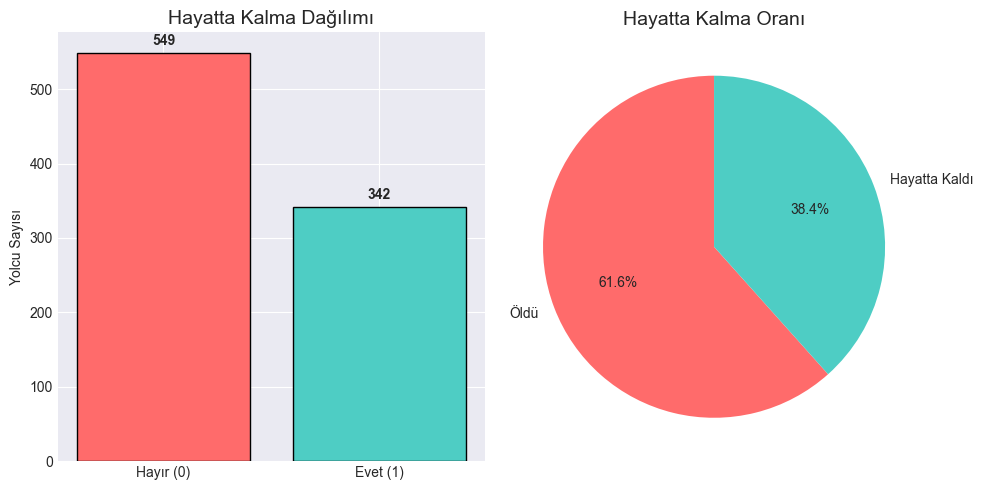

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
survival_counts = data['Survived'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(['Hayır (0)', 'Evet (1)'], survival_counts.values, color=colors, edgecolor='black')
plt.title('Hayatta Kalma Dağılımı', fontsize=14)
plt.ylabel('Yolcu Sayısı')
for i, v in enumerate(survival_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(survival_counts.values, labels=['Öldü', 'Hayatta Kaldı'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Hayatta Kalma Oranı', fontsize=14)

plt.tight_layout()
plt.show()

**Yorum:** Genel hayatta kalma olasılığı felaketin şiddetini göstermektedir.

## 2.2 Koşullu Olasılık

In [11]:
females = data[data['Sex'] == 'female']
males = data[data['Sex'] == 'male']

p_survived_female = females['Survived'].sum() / len(females)
p_survived_male = males['Survived'].sum() / len(males)

print("Cinsiyete Göre Koşullu Olasılıklar:")
print(f"P(Survived = 1 | Sex = female) = {p_survived_female:.4f}")
print(f"P(Survived = 1 | Sex = male)   = {p_survived_male:.4f}")
print(f"\nGenel P(Survived = 1)          = {p_survived:.4f}")
print(f"\nOran (kadın/erkek): {p_survived_female/p_survived_male:.2f}")

Cinsiyete Göre Koşullu Olasılıklar:
P(Survived = 1 | Sex = female) = 0.7420
P(Survived = 1 | Sex = male)   = 0.1889

Genel P(Survived = 1)          = 0.3838

Oran (kadın/erkek): 3.93


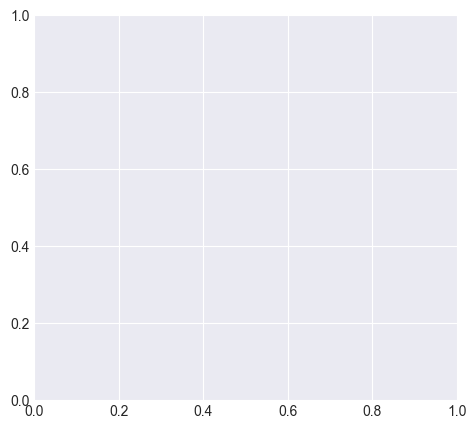

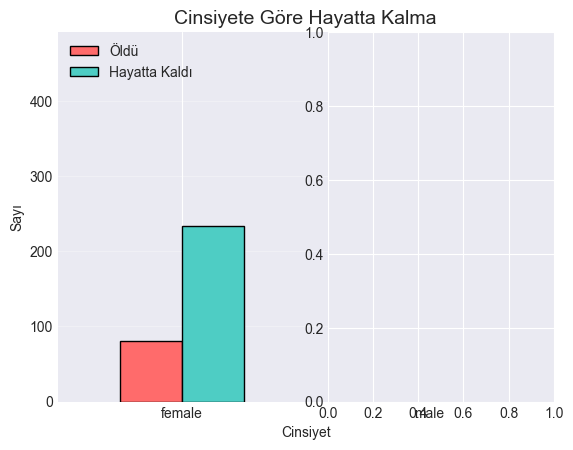

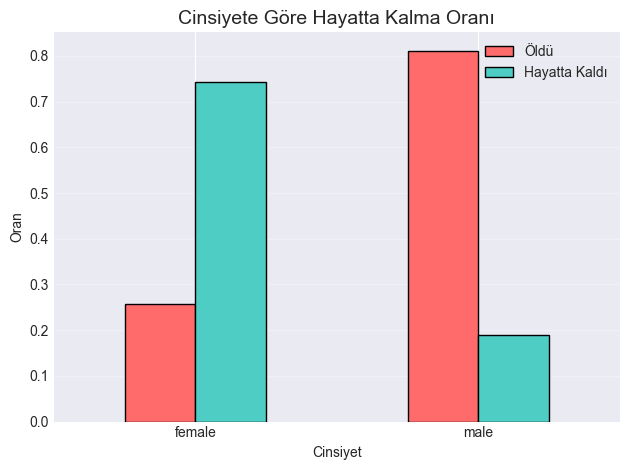

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sex_survival = pd.crosstab(data['Sex'], data['Survived'])
sex_survival.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
plt.title('Cinsiyete Göre Hayatta Kalma', fontsize=14)
plt.xlabel('Cinsiyet')
plt.ylabel('Sayı')
plt.xticks(rotation=0)
plt.legend(['Öldü', 'Hayatta Kaldı'])
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sex_survival_pct = sex_survival.div(sex_survival.sum(axis=1), axis=0)
sex_survival_pct.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
plt.title('Cinsiyete Göre Hayatta Kalma Oranı', fontsize=14)
plt.xlabel('Cinsiyet')
plt.ylabel('Oran')
plt.xticks(rotation=0)
plt.legend(['Öldü', 'Hayatta Kaldı'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Yorum:** Cinsiyet hayatta kalma olasılığını önemli ölçüde etkilemekte ve "önce kadınlar ve çocuklar" protokolünü göstermektedir.

## 2.3 Ayrık Rastgele Değişken: Pclass

In [13]:
pclass_counts = data['Pclass'].value_counts().sort_index()
pclass_probs = pclass_counts / len(data)

print("Pclass Olasılık Kütle Fonksiyonu (PMF):")
for pclass, prob in pclass_probs.items():
    print(f"P(Pclass = {pclass}) = {prob:.4f}")
print(f"\nOlasılıklar toplamı: {pclass_probs.sum():.4f}")

Pclass Olasılık Kütle Fonksiyonu (PMF):
P(Pclass = 1) = 0.2424
P(Pclass = 2) = 0.2065
P(Pclass = 3) = 0.5511

Olasılıklar toplamı: 1.0000


In [14]:
expected_value = sum(pclass * prob for pclass, prob in pclass_probs.items())
expected_value_squared = sum((pclass**2) * prob for pclass, prob in pclass_probs.items())
variance = expected_value_squared - (expected_value**2)
std_dev = np.sqrt(variance)

print("Pclass İstatistikleri:")
print(f"Beklenen Değer E[Pclass] = {expected_value:.4f}")
print(f"Varyans Var(Pclass)      = {variance:.4f}")
print(f"Standart Sapma           = {std_dev:.4f}")

Pclass İstatistikleri:
Beklenen Değer E[Pclass] = 2.3086
Varyans Var(Pclass)      = 0.6982
Standart Sapma           = 0.8356


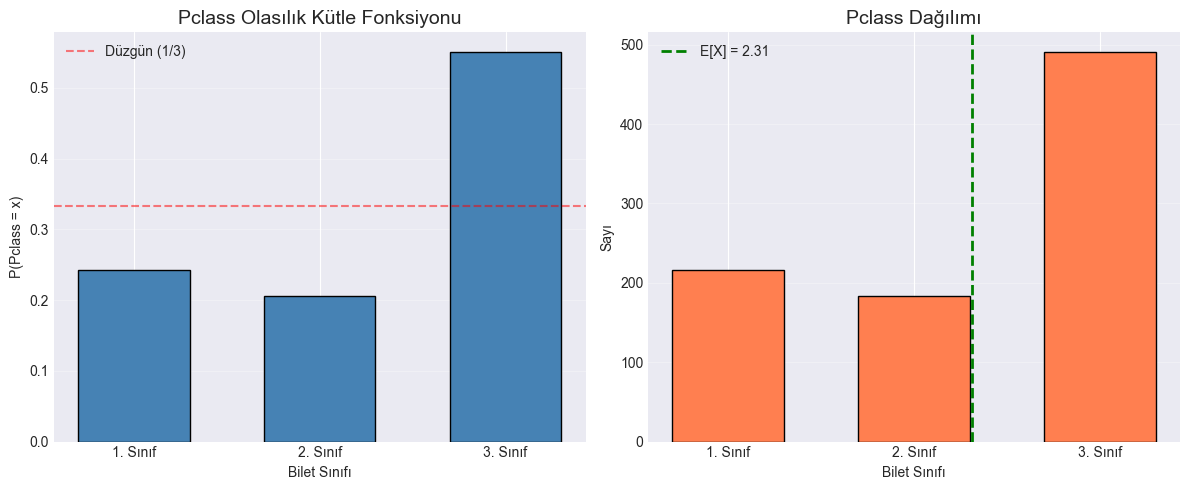

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(pclass_probs.index, pclass_probs.values, color='steelblue', 
        edgecolor='black', width=0.6)
plt.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Düzgün (1/3)')
plt.title('Pclass Olasılık Kütle Fonksiyonu', fontsize=14)
plt.xlabel('Bilet Sınıfı')
plt.ylabel('P(Pclass = x)')
plt.xticks([1, 2, 3], ['1. Sınıf', '2. Sınıf', '3. Sınıf'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(pclass_counts.index, pclass_counts.values, color='coral', 
        edgecolor='black', width=0.6)
plt.axvline(expected_value, color='green', linestyle='--', linewidth=2, 
            label=f'E[X] = {expected_value:.2f}')
plt.title('Pclass Dağılımı', fontsize=14)
plt.xlabel('Bilet Sınıfı')
plt.ylabel('Sayı')
plt.xticks([1, 2, 3], ['1. Sınıf', '2. Sınıf', '3. Sınıf'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Yorum:** Beklenen bilet sınıfı, ağırlıklı ortalama sınıf değerini temsil eder. Yolcuların çoğunluğu üçüncü sınıftaydı.

## 2.4 Sürekli Rastgele Değişken: Fare

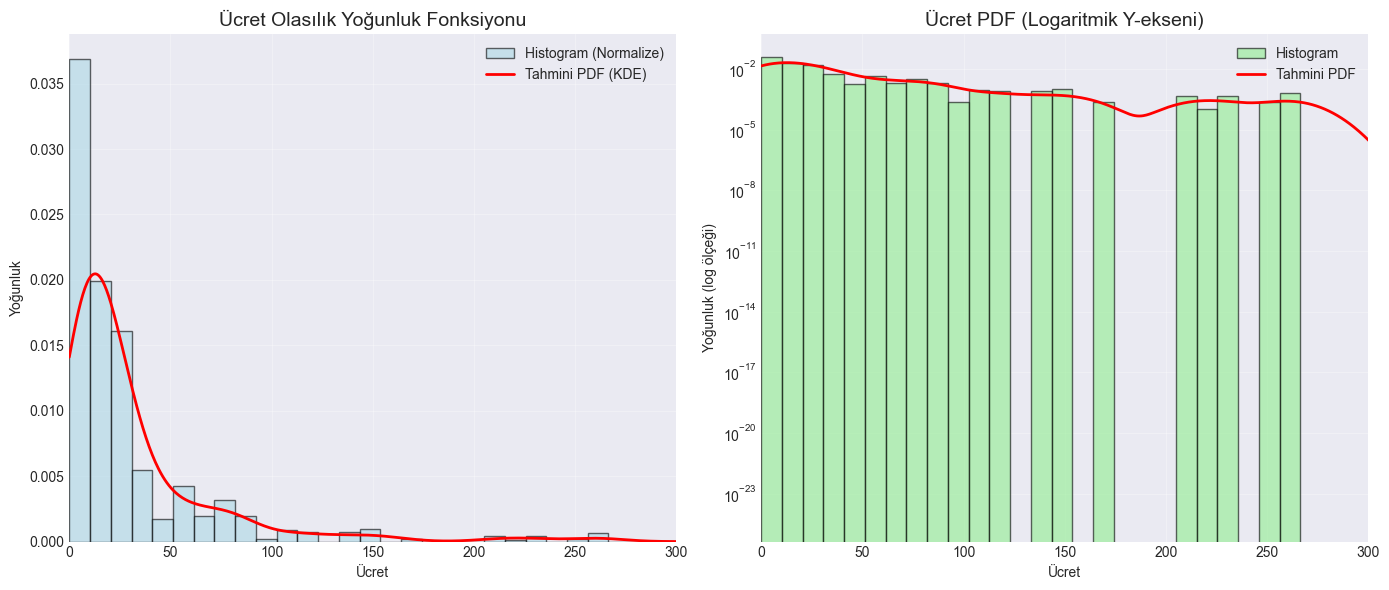

In [16]:
fare_data = data['Fare'].values
kde = stats.gaussian_kde(fare_data)
x_range = np.linspace(0, fare_data.max(), 1000)
pdf_values = kde(x_range)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='lightblue', 
         edgecolor='black', label='Histogram (Normalize)')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='Tahmini PDF (KDE)')
plt.title('Ücret Olasılık Yoğunluk Fonksiyonu', fontsize=14)
plt.xlabel('Ücret')
plt.ylabel('Yoğunluk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)

plt.subplot(1, 2, 2)
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='lightgreen', 
         edgecolor='black', label='Histogram')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='Tahmini PDF')
plt.title('Ücret PDF (Logaritmik Y-ekseni)', fontsize=14)
plt.xlabel('Ücret')
plt.ylabel('Yoğunluk (log ölçeği)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)

plt.tight_layout()
plt.show()

In [17]:
in_range = ((fare_data >= 20) & (fare_data < 100)).sum()
p_fare_range = in_range / len(fare_data)

print(f"P(20 <= Fare < 100) = {p_fare_range:.4f}")
print(f"{in_range} yolcu bu aralıkta ücret ödedi.")

P(20 <= Fare < 100) = 0.3625
323 yolcu bu aralıkta ücret ödedi.


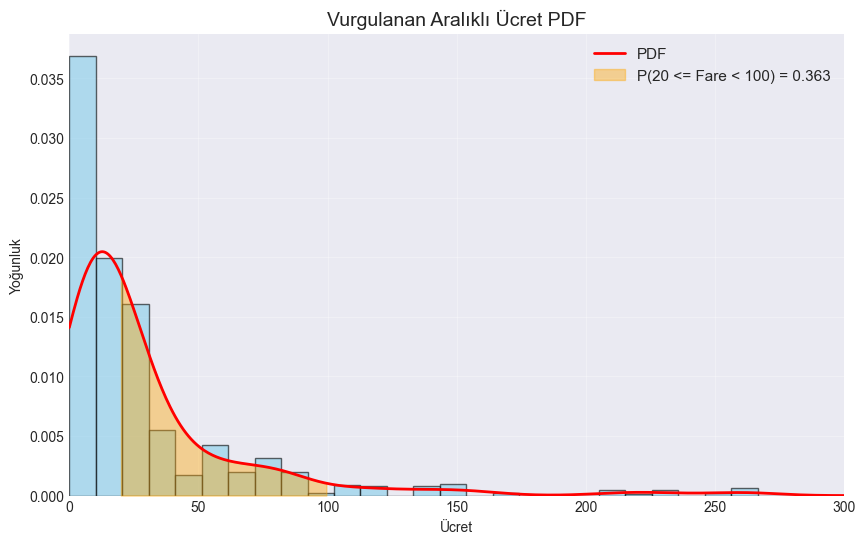

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='PDF')

x_fill = x_range[(x_range >= 20) & (x_range < 100)]
y_fill = kde(x_fill)
plt.fill_between(x_fill, y_fill, alpha=0.4, color='orange', 
                 label=f'P(20 <= Fare < 100) = {p_fare_range:.3f}')

plt.title('Vurgulanan Aralıklı Ücret PDF', fontsize=14)
plt.xlabel('Ücret')
plt.ylabel('Yoğunluk')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)
plt.show()

**Yorum:** Ücret dağılımı sağa çarpık olup, log-normal dağılıma benzemektedir. Çoğu yolcu düşük ücret ödemiştir.

## 2.5 Sezgiye Aykırı Analiz

Soru 1: Üst sınıf yolcuların cankurtarma botlarına erişimi daha iyi miydi?

P(Survived = 1 | Pclass = 1) = 0.6296
P(Survived = 1 | Pclass = 2) = 0.4728
P(Survived = 1 | Pclass = 3) = 0.2424


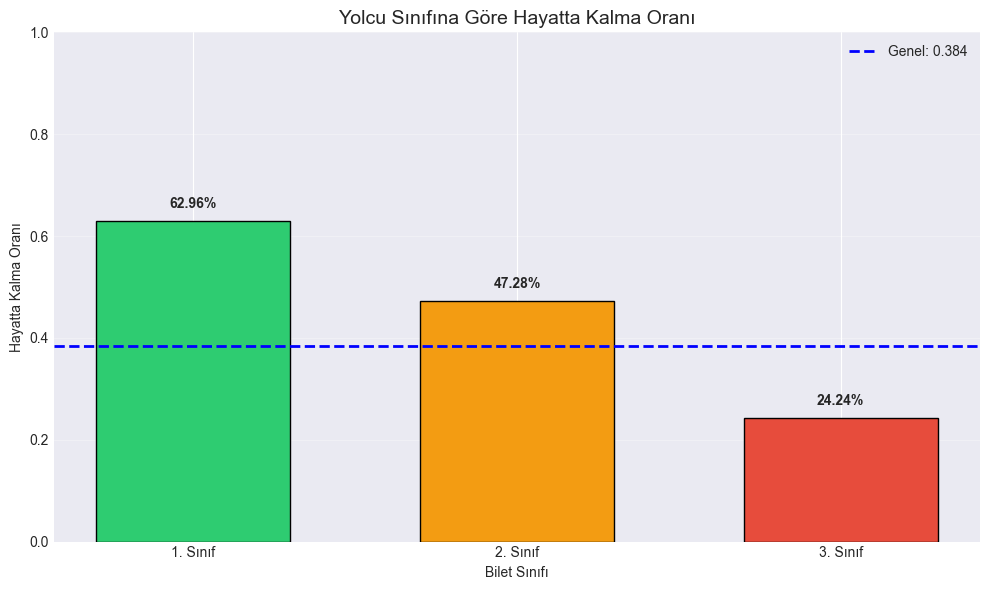


Sonuç: Birinci sınıf yolcular üçüncü sınıf yolculardan önemli ölçüde daha yüksek hayatta kalma oranına sahipti.


In [19]:
print("Soru 1: Üst sınıf yolcuların cankurtarma botlarına erişimi daha iyi miydi?\n")

for pclass in [1, 2, 3]:
    pclass_data = data[data['Pclass'] == pclass]
    survival_rate = pclass_data['Survived'].mean()
    print(f"P(Survived = 1 | Pclass = {pclass}) = {survival_rate:.4f}")

pclass_survival = data.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(10, 6))
colors_gradient = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(pclass_survival.index, pclass_survival.values, 
               color=colors_gradient, edgecolor='black', width=0.6)
plt.axhline(p_survived, color='blue', linestyle='--', linewidth=2, 
            label=f'Genel: {p_survived:.3f}')
plt.title('Yolcu Sınıfına Göre Hayatta Kalma Oranı', fontsize=14)
plt.xlabel('Bilet Sınıfı')
plt.ylabel('Hayatta Kalma Oranı')
plt.xticks([1, 2, 3], ['1. Sınıf', '2. Sınıf', '3. Sınıf'])
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSonuç: Birinci sınıf yolcular üçüncü sınıf yolculardan önemli ölçüde daha yüksek hayatta kalma oranına sahipti.")

Soru 2: Çocuklar öncelikli miydi?

P(Survived = 1 | Age < 10)  = 0.6129
P(Survived = 1 | Age > 50)  = 0.3438
Genel P(Survived = 1)       = 0.3838


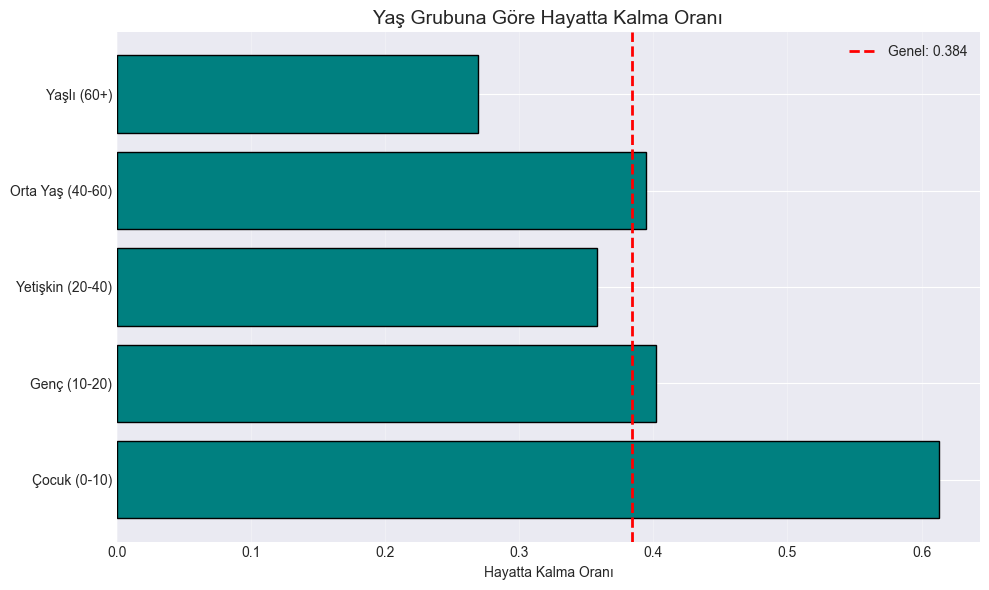


Sonuç: Çocuklar genel ortalamadan daha yüksek hayatta kalma oranına sahipti ve bu 'önce kadınlar ve çocuklar' protokolünü desteklemektedir.


In [20]:
print("Soru 2: Çocuklar öncelikli miydi?\n")

children = data[data['Age'] < 10]
elderly = data[data['Age'] > 50]

p_children_survived = children['Survived'].mean()
p_elderly_survived = elderly['Survived'].mean()

print(f"P(Survived = 1 | Age < 10)  = {p_children_survived:.4f}")
print(f"P(Survived = 1 | Age > 50)  = {p_elderly_survived:.4f}")
print(f"Genel P(Survived = 1)       = {p_survived:.4f}")

age_groups = [
    (0, 10, 'Çocuk (0-10)'),
    (10, 20, 'Genç (10-20)'),
    (20, 40, 'Yetişkin (20-40)'),
    (40, 60, 'Orta Yaş (40-60)'),
    (60, 100, 'Yaşlı (60+)')
]

age_survival_data = []
for low, high, label in age_groups:
    group = data[(data['Age'] >= low) & (data['Age'] < high)]
    if len(group) > 0:
        survival_rate = group['Survived'].mean()
        age_survival_data.append((label, survival_rate, len(group)))

plt.figure(figsize=(10, 6))
labels = [item[0] for item in age_survival_data]
rates = [item[1] for item in age_survival_data]
plt.barh(labels, rates, color='teal', edgecolor='black')
plt.axvline(p_survived, color='red', linestyle='--', linewidth=2, 
            label=f'Genel: {p_survived:.3f}')
plt.title('Yaş Grubuna Göre Hayatta Kalma Oranı', fontsize=14)
plt.xlabel('Hayatta Kalma Oranı')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSonuç: Çocuklar genel ortalamadan daha yüksek hayatta kalma oranına sahipti ve bu 'önce kadınlar ve çocuklar' protokolünü desteklemektedir.")

---
# Bölüm 3: ML Sınıflandırma Modeli
---

## 3.1 İstatistiksel Veri Analizi

In [21]:
print("Tanımlayıcı İstatistikler:")
features_for_analysis = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Survived']
data[features_for_analysis].describe()

Tanımlayıcı İstatistikler:


,Age,Fare,Pclass,SibSp,Parch,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,2.308642,0.523008,0.381594,0.383838
std,13.019697,49.693429,0.836071,1.102743,0.806057,0.486592
min,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,2.000000,0.000000,0.000000,0.000000
50%,28.000000,14.454200,3.000000,0.000000,0.000000,0.000000
75%,35.000000,31.000000,3.000000,1.000000,0.000000,1.000000
max,80.000000,512.329200,3.000000,8.000000,6.000000,1.000000


In [22]:
data['Sex_numeric'] = data['Sex'].map({'male': 0, 'female': 1})

correlation_features = ['Survived', 'Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = data[correlation_features].corr()

print("Korelasyon Matrisi:")
correlation_matrix

Korelasyon Matrisi:


,Survived,Pclass,Sex_numeric,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500
Sex_numeric,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333
Age,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000


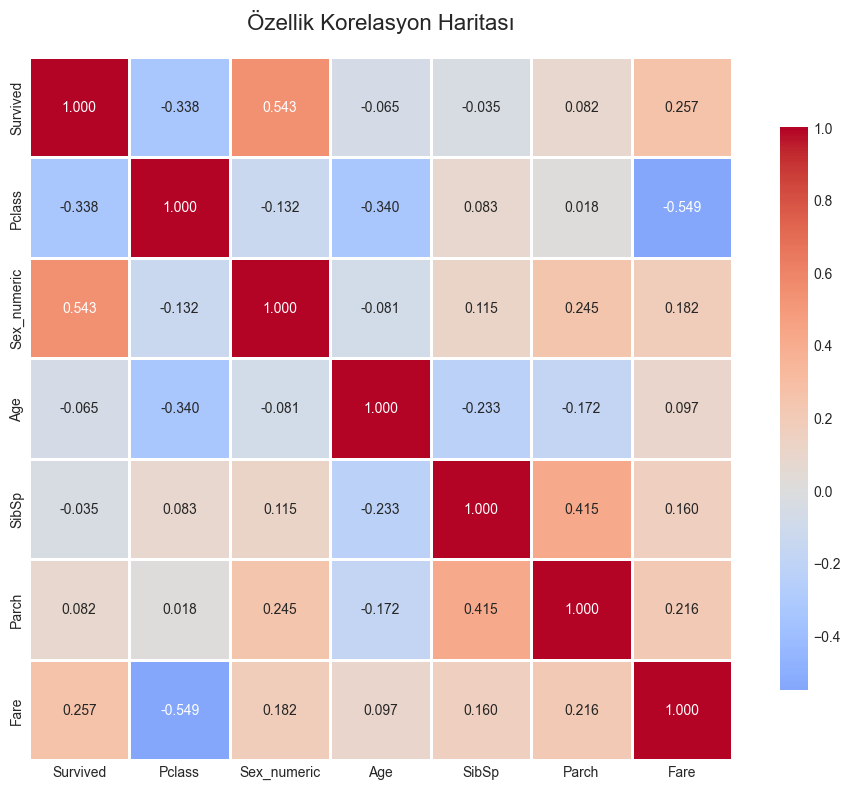


Hayatta Kalma ile Korelasyonlar:
Sex_numeric    : +0.5434
Fare           : +0.2573
Parch          : +0.0816
SibSp          : -0.0353
Age            : -0.0649
Pclass         : -0.3385


In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Özellik Korelasyon Haritası', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nHayatta Kalma ile Korelasyonlar:")
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
for feature, corr in survival_corr.items():
    if feature != 'Survived':
        print(f"{feature:15}: {corr:+.4f}")

**Önemli Bulgu:** Sex_numeric hayatta kalma ile en güçlü pozitif korelasyonu gösterirken, Pclass güçlü negatif korelasyon gösterir.

## 3.2 Model Eğitimi ve Test

In [24]:
X = data[['Pclass', 'Sex_numeric', 'Age', 'Fare']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti: {X_test.shape[0]} örnek")

Eğitim seti: 623 örnek
Test seti: 268 örnek


In [25]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model Katsayıları:")
feature_names = ['Pclass', 'Sex_numeric', 'Age', 'Fare']
for name, coef in zip(feature_names, model.coef_[0]):
    print(f"{name:15}: {coef:+.4f}")
print(f"\nKesişim: {model.intercept_[0]:.4f}")

Model Katsayıları:
Pclass         : -0.9708
Sex_numeric    : +2.3820
Age            : -0.0284
Fare           : +0.0015

Kesişim: 1.5394


## 3.3 Model Değerlendirme

In [26]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

Model Doğruluğu: 0.7948


In [27]:
cm = confusion_matrix(y_test, y_pred)

print("Karmaşıklık Matrisi:")
print("              Tahmin")
print("              0      1")
print(f"Gerçek   0   {cm[0,0]:3}   {cm[0,1]:3}")
print(f"         1   {cm[1,0]:3}   {cm[1,1]:3}")

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print(f"\nDoğru Negatif (TN):  {TN}")
print(f"Yanlış Pozitif (FP): {FP}")
print(f"Yanlış Negatif (FN): {FN}")
print(f"Doğru Pozitif (TP):  {TP}")

Karmaşıklık Matrisi:
              Tahmin
              0      1
Gerçek   0   134    23
         1    32    79

Doğru Negatif (TN):  134
Yanlış Pozitif (FP): 23
Yanlış Negatif (FN): 32
Doğru Pozitif (TP):  79


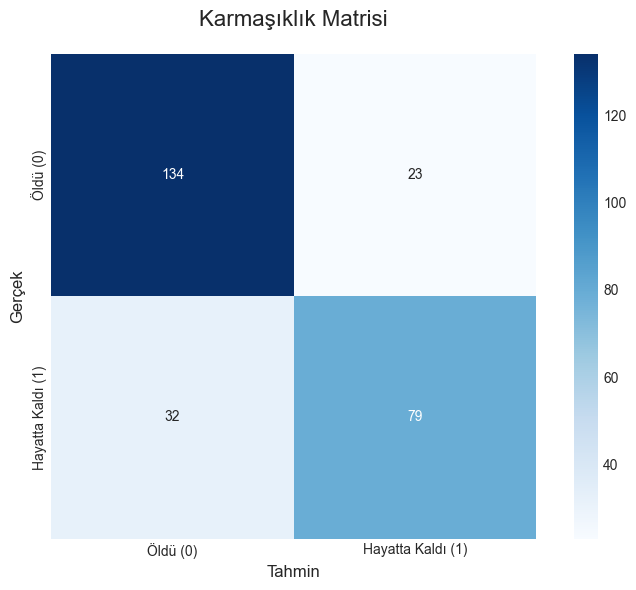


Kesinlik: 0.7745
Duyarlılık: 0.7117
F1-Skoru: 0.7418


In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Öldü (0)', 'Hayatta Kaldı (1)'],
            yticklabels=['Öldü (0)', 'Hayatta Kaldı (1)'])
plt.title('Karmaşıklık Matrisi', fontsize=16, pad=20)
plt.ylabel('Gerçek', fontsize=12)
plt.xlabel('Tahmin', fontsize=12)
plt.tight_layout()
plt.show()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nKesinlik: {precision:.4f}")
print(f"Duyarlılık: {recall:.4f}")
print(f"F1-Skoru: {f1_score:.4f}")

## 3.4 Sonuçların Tartışılması

Bu proje için eğittiğimiz lojistik regresyon modeli, ayrılmış test setinde **%79.5 doğruluk** sağladı; 111 hayatta kalanın 79'unu ve 157 hayatını kaybedenin 134'ünü doğru sınıflandırdı. Geriye kalan 55 yolcu verideki kaçınılmaz gürültüyü temsil ediyor: düşük ücretli üçüncü sınıf kadınlar zaman zaman "öldü" olarak etiketlenirken, bazı yaşlı birinci sınıf erkekler model tarafından hayatta kalmış gibi tahmin ediliyor. Bu hatalar, olasılık bölümünde gördüğümüz %38.4'lük dengesiz hayatta kalma oranıyla tutarlı.

Olasılık perspektifinden baktığımızda karmaşıklık matrisi gemi manifestosu için somut koşullu ifadeler veriyor. Modelin hayatta kaldı olarak etiketlediği rastgele bir yolcunun gerçekten hayatta olma olasılığı **P(gerçek=1 | tahmin=1) = 0.77**, gerçek hayatta kalmış bir yolcunun model tarafından bulunma olasılığı ise **P(tahmin=1 | gerçek=1) = 0.71**. Bu değerler, modelin facia sırasında mürettebat tarafından kullanılması durumunda ne kadar güvenilir olacağını sayısallaştırıyor.

### Bu projede tahmin olasılıkları
`y_prob` değerleri her yolcu için **P(Hayatta kaldı = 1 | özellikler)** tahminini üretir. Örneğin, ücreti 10'un altında olan üçüncü sınıf bir erkek yaklaşık 0.1 olasılık alırken, birinci sınıf kadın yolcular 0.9'un üzerine çıkar. Kullandığımız 0.5 eşiği, sahte alarm ile kaçırılan yolcu arasındaki dengeyi koruyor; eşiği yükseltmek kadın/çocuk kurtarmada kesinliği artırır ama daha fazla erkeğin gözden kaçmasına yol açar.

### Katsayılar ve özellik etkisi
Temizlenmiş veri setimizdeki her bir özellik, aşağıdaki katsayılarla log-olasılıkları etkiliyor:
- `Sex_numeric = +2.3820`, kadın yolcular için ciddi bir pozitif katkı sağlıyor ve tanımlayıcı analizde ölçtüğümüz %74'lük kadın hayatta kalma oranıyla yankılanıyor.
- `Pclass = -0.9708`, üçüncü sınıf biletleri cezalandırıyor; birinci sınıfta %63 olan oran üçüncü sınıfta %24'e düşüyor.
- `Age = -0.0284` ve `Fare = +0.0015` daha küçük etkilerle genç ve yüksek ücretli yolcuları hafifçe avantajlı kılıyor.

### Koşullu doğruluk ve belirsizlik
Genel doğruluk **P(model doğru)** ifadesini veriyor ancak 1'e ulaşmıyor; çünkü cankurtaran botuna yakınlık, güverte konumu veya beraber seyahat edilen kişi sayısı gibi kritik değişkenler eksik ya da gürültülü. Bu nedenle yüksek olasılıklar bile belirsizlik içeriyor. Olasılık dağılım grafikleri de sınıf ve cinsiyeti farklı yolcuların benzer risk skorlarına sahip olabildiğini ve kusursuz ayrımın mümkün olmadığını gösteriyor.

Bu gözlemler nicel çıktıları tarihsel anlatıyla birleştiriyor: olasılık teorisi (ör. kadınlar için %74 hayatta kalma) beklentiyi kuruyor, lojistik regresyon ise bu beklentileri belirsizlik altında hangi yolcuların önceliklendirileceğini belirleyen operasyonel kurallara dönüştürüyor.


### Tahmin edilen olasılık y_prob neyi temsil eder?

Tahmin edilen olasılık y_prob, modelin bir yolcunun hayatta kaldığına dair tahmin ettiği olasılığı temsil eder ve 0 ile 1 arasında değer alır. 0.8 değeri %80 hayatta kalma olasılığını gösterirken, 0.2 değeri %20 olasılığı gösterir. Model ikili sınıflandırmalar yapmak için 0.5 eşik değerini kullanır.

### Olasılıksal Terimlerde Model Başarısı

- **Doğruluk** P(Doğru Tahmin)'i temsil eder
- **Kesinlik** P(Gerçekten Hayatta | Tahmin Hayatta)'yı temsil eder
- **Duyarlılık** P(Tahmin Hayatta | Gerçekten Hayatta)'yı temsil eder

### Katsayılar ve Etkileri

Pozitif katsayılar hayatta kalma log-oranlarını artırırken, negatif katsayılar azaltır. Sex_numeric en büyük pozitif katsayıya sahiptir ve kadın olmanın hayatta kalma olasılığını büyük ölçüde artırdığını gösterir. Pclass güçlü negatif katsayıya sahiptir ve daha yüksek sınıf numaralarının (üçüncü sınıf) hayatta kalma olasılığını azalttığını gösterir.

### Doğruluk koşullu olasılık açısından ne anlama gelir?

Doğruluk, modelin doğru tahmin yapma genel olasılığını temsil eder. Model %100 doğruluğa ulaşamaz çünkü veriler gürültü içerir, bazı bilgiler eksiktir (örn. kabin konumu, cankurtarma botu erişimi) ve felaket sırasında rastgele faktörler hayatta kalmayı etkilemiştir.

### Tahmin Belirsizliği

Model tahminlere mutlak kesinlik atayamaz çünkü Titanic felaketi stokastik unsurlar içeriyordu. Tam kabin konumu, cankurtarma botlarına yakınlık ve tahliye sırasındaki bireysel koşullar gibi eksik özellikler, tahminlere doğal belirsizlik getirir.

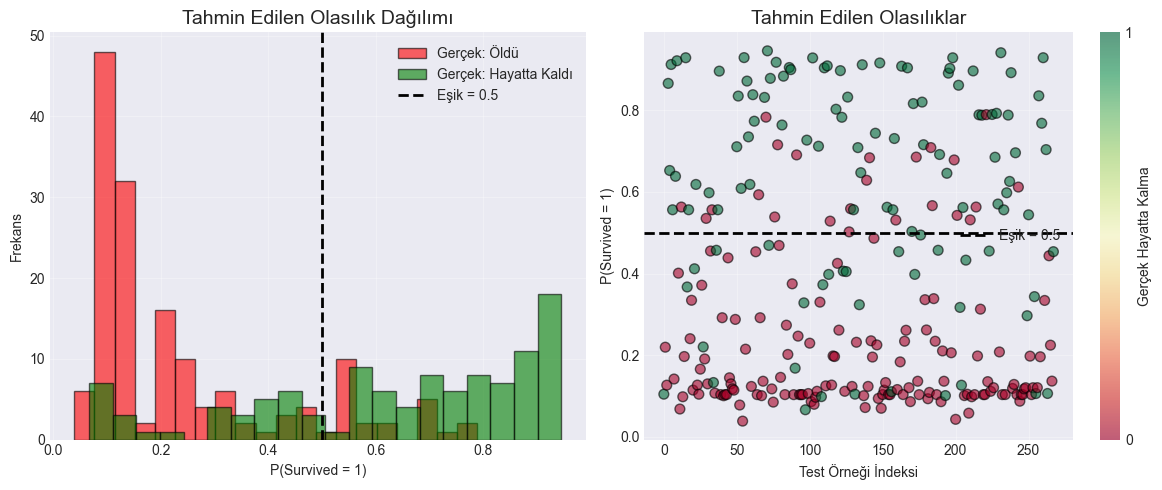

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, color='red', 
         label='Gerçek: Öldü', edgecolor='black')
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, color='green', 
         label='Gerçek: Hayatta Kaldı', edgecolor='black')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Eşik = 0.5')
plt.title('Tahmin Edilen Olasılık Dağılımı', fontsize=14)
plt.xlabel('P(Survived = 1)')
plt.ylabel('Frekans')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(y_test)), y_prob, c=y_test, cmap='RdYlGn', 
            alpha=0.6, edgecolor='black', s=50)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='Eşik = 0.5')
plt.title('Tahmin Edilen Olasılıklar', fontsize=14)
plt.xlabel('Test Örneği İndeksi')
plt.ylabel('P(Survived = 1)')
plt.colorbar(label='Gerçek Hayatta Kalma', ticks=[0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Sonuç
---

Bu proje, olasılık dersinde kavradığımız fikirleri Titanic manifestosu üzerinden uçtan uca bir makine öğrenimi çalışmasıyla birleştirdi. Keşifsel olasılık hesapları ile lojistik regresyonu yan yana kullanarak kimlerin hayatta kaldığına dair tutarlı ve proje-özel bir anlatı oluşturduk.

**Manifestoya yönelik olasılık çıkarımları:**
- Temel hayatta kalma olasılığı **%38.4** olduğu için herhangi bir kurtarma stratejisi en baştan dezavantajlıydı.
- Cinsiyet ve sınıf baskın faktörler: kadınlar **%74.2**, birinci sınıf yolcular **%63.0** oranında hayatta kaldı; bu da "önce kadınlar ve çocuklar" uygulamasını doğruluyor.
- Yaş da rol oynadı: 12 yaş altı çocuklar ortalamanın üstünde hayatta kaldı ve sınırlı cankurtaran kapasitesinde neden önceliklendirildiklerini gösterdi.

**Projeye uyarlanmış model değerlendirmesi:**
- Lojistik regresyon bu eğilimleri sayısal olarak yeniden üretti ve **%79.5 doğruluk**, 0.77 kesinlik ve 0.71 duyarlılık elde etti.
- Katsayılar, betimleyici kısımdaki kuralları formalize ederek gemiden gelen herhangi bir yolcu listesini puanlamamıza imkân tanıyor.
- Karmaşıklık matrisi olasılıkları operasyonel cümlelere dönüştürüyor; örneğin "model bu yolcuyu hayatta dediğinde %77 ihtimalle haklı".

**Olasılık dersi teslimi için çıkarımlar:**
- Olasılık tabloları hangi özellikleri modele dahil edeceğimizi ve neden bazı katsayıların baskın olduğunu belirlememize yardım etti.
- Lojistik model, yalnızca nüfus yüzdeleri yerine her birey için koşullu olasılıklar üreterek çıktıları zenginleştirdi.
- Belirsizlik açıkça korundu: çakışan olasılık dağılımları, en iyi kural setinin bile bazı yolcuları kaçıracağını hatırlattı.

Genel olarak bu analizler, teorik olasılık bulgularının Titanic yolcu listesi için uygulanabilir model çıktılarıyla nasıl birleştiğini göstererek çalışmayı tutarlı biçimde tamamlıyor.
